# Script to write rainy season characteristics following Bombardi et al. (2019) 

In [1]:
import os
import sys

import numpy as np
import xarray as xr

import matplotlib as mpl
import matplotlib.pyplot as plt

import math

import cftime
from datetime import timedelta, date
from pathlib import Path

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf


import warnings
warnings.filterwarnings("ignore")

In [2]:
# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")

# ── Configuration ─────────────────────────────────────────────────────────────

MODELS = {
    "UKESM1-0-LL":   {"institution": "MOHC",         "ensemble": "r1i1p1f2", "grid": "gn"},
    "CNRM-ESM2-1":   {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2", "grid": "gr"},
    "MPI-ESM1-2-LR": {"institution": "MPI-M",        "ensemble": "r1i1p1f1", "grid": "gn"},
    "CESM2-WACCM":   {"institution": "NCAR",         "ensemble": "r1i1p1f1", "grid": "gn"},
    "IPSL-CM6A-LR":  {"institution": "IPSL",         "ensemble": "r1i1p1f1", "grid": "gr"},
}

EXPERIMENTS = {
    "piControl":     {"project": "CMIP",        "scenario": "piControl",  "color": "black"},
    "HIST":     {"project": "CMIP",        "scenario": "historical"},
    "SSP245":   {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":   {"project": "ScenarioMIP", "scenario": "ssp585"},
    # "G6solar":  {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur": {"project": "GeoMIP",      "scenario": "G6sulfur"},
    "G6solar":  {"project": "GeoMIP",      "scenario": "G6solar"},
}

varname  = "pr"

In [3]:

# # ── Main loop ─────────────────────────────────────────────────────────────────

# for model_name, model_meta in MODELS.items():
#     for exp, meta in EXPERIMENTS.items():
#         # ── CESM2-WACCM ensemble override ─────────────────────────────────
#         if model_name == "CESM2-WACCM":
#             ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#         else:
#             ensemble = model_meta["ensemble"]

#         base = (
#             CEDA_BASE
#             / meta["project"]
#             / model_meta["institution"]
#             / model_name
#             / meta["scenario"]
#             / ensemble
#             / "day"
#             / varname
#             / model_meta["grid"]
#             / "latest"
#         )

#         try:
#             ds = mf.open_files(str(base))
#             da = mf.read_var(ds, varname)

#             time = da.time
#             year_min = int(time.dt.year.min())
#             year_max = int(time.dt.year.max())
#             n_years = len(np.unique(time.dt.year.values))

#             print(f"  {model_name:<20} {exp:<15} {year_min}–{year_max}  ({n_years} years)")

#         except Exception as e:
#             print(f"  {model_name:<20} {exp:<15} FAILED: {e}")

In [7]:
import re

summary = {}

for model_name, model_meta in MODELS.items():
    for exp, meta in EXPERIMENTS.items():
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "day"
            / varname
            / model_meta["grid"]
            / "latest"
        )

        try:
            files = sorted(base.glob("*.nc"))
            if not files:
                summary[(model_name, exp)] = "NO FILES"
                continue

            # Extract all years from filename date ranges like _19800101-19901231.nc
            years = []
            for f in files:
                match = re.search(r'_(\d{4})\d{4}-(\d{4})\d{4}\.nc$', f.name)
                if match:
                    years.append(int(match.group(1)))
                    years.append(int(match.group(2)))

            if years:
                year_min, year_max = min(years), max(years)
                n_years = year_max - year_min + 1
                summary[(model_name, exp)] = f"{year_min}–{year_max} ({n_years} yrs)"
            else:
                summary[(model_name, exp)] = f"{len(files)} files (dates unparsed)"

        except Exception as e:
            summary[(model_name, exp)] = f"FAILED: {e}"

# ── Pretty print ──────────────────────────────────────────────────────────────
exps = list(EXPERIMENTS.keys())
col_w = 23

header = f"{'Model':<25}" + "".join(f"{e:<{col_w}}" for e in exps)
print("\n" + "="*len(header))
print(header)
print("="*len(header))
for model_name in MODELS:
    row = f"{model_name:<25}"
    for exp in exps:
        row += f"{summary.get((model_name, exp), 'N/A'):<{col_w}}"
    print(row)
print("="*len(header))


Model                    piControl              HIST                   SSP245                 SSP585                 G6sulfur               G6solar                
UKESM1-0-LL              1960–3059 (1100 yrs)   1850–2014 (165 yrs)    2015–2100 (86 yrs)     2015–2100 (86 yrs)     2020–2100 (81 yrs)     2020–2100 (81 yrs)     
CNRM-ESM2-1              1850–2349 (500 yrs)    1850–2014 (165 yrs)    2015–2100 (86 yrs)     2015–2100 (86 yrs)     2015–2100 (86 yrs)     2015–2100 (86 yrs)     
MPI-ESM1-2-LR            1850–2849 (1000 yrs)   1850–2014 (165 yrs)    2015–2100 (86 yrs)     2015–2100 (86 yrs)     2015–2099 (85 yrs)     2015–2099 (85 yrs)     
CESM2-WACCM              1–500 (500 yrs)        1850–2015 (166 yrs)    2015–2101 (87 yrs)     2015–2300 (286 yrs)    2020–2101 (82 yrs)     2019–2101 (83 yrs)     
IPSL-CM6A-LR             1850–3849 (2000 yrs)   1850–2014 (165 yrs)    2015–2100 (86 yrs)     2015–2300 (286 yrs)    2020–2100 (81 yrs)     2020–2100 (81 yrs)     


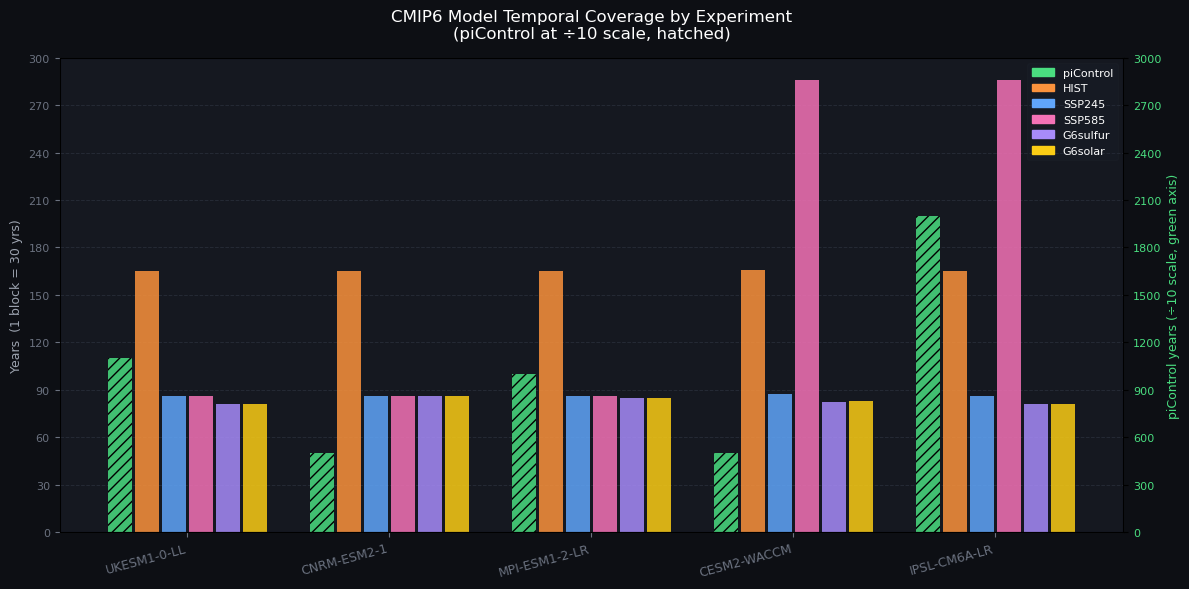

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

data = {
    "UKESM1-0-LL":   {"piControl": 1100, "HIST": 165, "SSP245": 86, "SSP585": 86,  "G6sulfur": 81,  "G6solar": 81},
    "CNRM-ESM2-1":   {"piControl": 500,  "HIST": 165, "SSP245": 86, "SSP585": 86,  "G6sulfur": 86,  "G6solar": 86},
    "MPI-ESM1-2-LR": {"piControl": 1000, "HIST": 165, "SSP245": 86, "SSP585": 86,  "G6sulfur": 85,  "G6solar": 85},
    "CESM2-WACCM":   {"piControl": 500,  "HIST": 166, "SSP245": 87, "SSP585": 286, "G6sulfur": 82,  "G6solar": 83},
    "IPSL-CM6A-LR":  {"piControl": 2000, "HIST": 165, "SSP245": 86, "SSP585": 286, "G6sulfur": 81,  "G6solar": 81},
}

BLOCK = 30  # years per block
SCALE_PICONTROL = 10  # piControl divided by this for visual sizing

colors = {
    "piControl": "#4ade80",
    "HIST":      "#fb923c",
    "SSP245":    "#60a5fa",
    "SSP585":    "#f472b6",
    "G6sulfur":  "#a78bfa",
    "G6solar":   "#facc15",
}

experiments = list(colors.keys())
models = list(data.keys())

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0d0f14")
ax.set_facecolor("#151820")

n_models = len(models)
n_exps = len(experiments)
group_width = 0.8
bar_width = group_width / n_exps

for i, model in enumerate(models):
    for j, exp in enumerate(experiments):
        years = data[model][exp]
        effective = years / SCALE_PICONTROL if exp == "piControl" else years
        n_blocks = effective / BLOCK
        x = i + (j - n_exps / 2 + 0.5) * bar_width
        ax.bar(x, n_blocks, width=bar_width * 0.9, color=colors[exp],
               alpha=0.85, linewidth=0,
               hatch="///" if exp == "piControl" else None)
        # no text annotations

# ax.autoscale(False)   # <-- add this line here, after the loop
# secondary y-axis ticks showing actual years
def blocks_to_years(b): return b * BLOCK
def years_to_blocks(y): return y / BLOCK

# yticks_blocks = np.arange(0, 75, 5)
yticks_blocks = np.arange(0, 11, 1)  # 0 to 10 blocks
ax.set_yticks(yticks_blocks)
ax.set_yticklabels([f"{int(b*BLOCK)}" for b in yticks_blocks], color="#9ca3af", fontsize=8)
ax.set_ylabel("Years  (1 block = 30 yrs)", color="#9ca3af", fontsize=9)

# piControl secondary axis note
ax2 = ax.twinx()
# ax2.set_ylim(0,100)
# # ax2.set_ylim(ax.get_ylim())
ax.set_ylim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_yticks(yticks_blocks)
ax2.set_yticklabels([f"{int(b*BLOCK*SCALE_PICONTROL)}" for b in yticks_blocks], color="#4ade80", fontsize=8)
ax2.set_ylabel("piControl years (÷10 scale, green axis)", color="#4ade80", fontsize=9)
ax2.set_facecolor("none")

ax.set_xticks(range(n_models))
ax.set_xticklabels(models, color="white", fontsize=9, rotation=15, ha="right")
ax.tick_params(colors="#6b7280", which="both")
for spine in ax.spines.values(): spine.set_edgecolor("#252a35")

ax.set_title("CMIP6 Model Temporal Coverage by Experiment\n(piControl at ÷10 scale, hatched)",
             color="white", fontsize=12, pad=14)
ax.grid(axis="y", color="#252a35", linewidth=0.7, linestyle="--")
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=colors[e], label=e,
                  hatch="///" if e == "piControl" else None) for e in experiments]
ax.legend(handles=legend_patches, loc="upper right", framealpha=0.2,
          labelcolor="white", facecolor="#1e2330", edgecolor="#252a35", fontsize=8)

plt.tight_layout()

plt.savefig("model_coverage.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

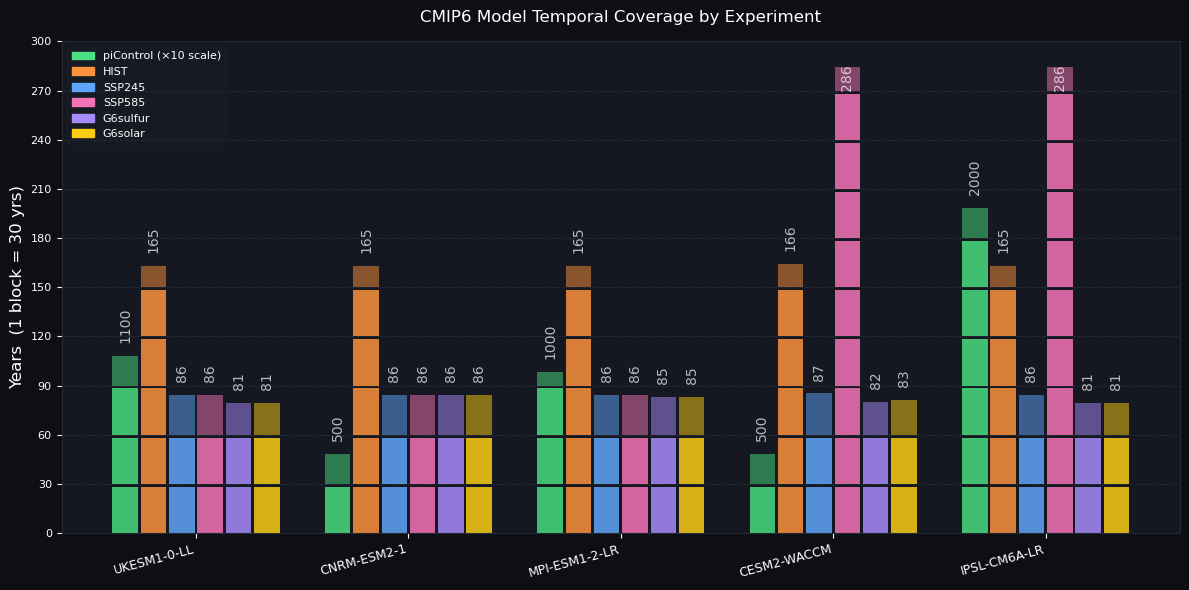

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

data = {
    "UKESM1-0-LL":   {"piControl": 1100, "HIST": 165, "SSP245": 86, "SSP585": 86,  "G6sulfur": 81,  "G6solar": 81},
    "CNRM-ESM2-1":   {"piControl": 500,  "HIST": 165, "SSP245": 86, "SSP585": 86,  "G6sulfur": 86,  "G6solar": 86},
    "MPI-ESM1-2-LR": {"piControl": 1000, "HIST": 165, "SSP245": 86, "SSP585": 86,  "G6sulfur": 85,  "G6solar": 85},
    "CESM2-WACCM":   {"piControl": 500,  "HIST": 166, "SSP245": 87, "SSP585": 286, "G6sulfur": 82,  "G6solar": 83},
    "IPSL-CM6A-LR":  {"piControl": 2000, "HIST": 165, "SSP245": 86, "SSP585": 286, "G6sulfur": 81,  "G6solar": 81},
}

BLOCK = 30
SCALE_PICONTROL = 10

colors = {
    "piControl": "#4ade80",
    "HIST":      "#fb923c",
    "SSP245":    "#60a5fa",
    "SSP585":    "#f472b6",
    "G6sulfur":  "#a78bfa",
    "G6solar":   "#facc15",
}

experiments = list(colors.keys())
models = list(data.keys())

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0d0f14")
ax.set_facecolor("#151820")

n_models = len(models)
n_exps = len(experiments)
group_width = 0.8
bar_width = group_width / n_exps

for i, model in enumerate(models):
    for j, exp in enumerate(experiments):
        years = data[model][exp]
        effective = years / SCALE_PICONTROL if exp == "piControl" else years
        n_blocks = effective / BLOCK  # float number of 30-yr blocks
        x = i + (j - n_exps / 2 + 0.5) * bar_width
        color = colors[exp]

        # Draw each 30-year block as a separate rectangle with a small gap
        full_blocks = int(n_blocks)
        remainder = n_blocks - full_blocks
        block_h = 1.0          # each block = 1 unit tall
        gap = 0.06             # gap between blocks

        for b in range(full_blocks):
            y_bottom = b * block_h
            ax.bar(x, block_h - gap, bottom=y_bottom, width=bar_width * 0.9,
                   color=color, alpha=0.85, linewidth=0)

        # partial top block
        if remainder > gap:
            y_bottom = full_blocks * block_h
            ax.bar(x, remainder - gap, bottom=y_bottom, width=bar_width * 0.9,
                   color=color, alpha=0.5, linewidth=0)

        # annotate actual years — cap y so text stays within axes
        text_y = min(n_blocks + 0.2, 9.0)  # keep text inside ylim=10 equivalent
        ax.text(x, text_y, str(years), ha="center", va="bottom",
                fontsize=10, color="white", alpha=0.7, rotation=90,
                clip_on=True)

yticks_blocks = np.arange(0, 11, 1)
ax.set_yticks(yticks_blocks)
ax.set_yticklabels([f"{int(b * BLOCK)}" for b in yticks_blocks], color="#9ca3af", fontsize=8)
# ax.set_ylabel("Years  (1 block = 30 yrs)", color="#9ca3af", fontsize=9)
ax.set_ylabel("Years  (1 block = 30 yrs)", color="white", fontsize=12)
ax.set_ylim(0, 10)

ax.set_xticks(range(n_models))
ax.set_xticklabels(models, color="white", fontsize=9, rotation=15, ha="right")
# ax.tick_params(colors="#6b7280", which="both")
ax.tick_params(colors="white", which="both")
for spine in ax.spines.values():
    spine.set_edgecolor("#252a35")

ax.set_title("CMIP6 Model Temporal Coverage by Experiment", color="white", fontsize=12, pad=14)
ax.grid(axis="y", color="#252a35", linewidth=0.7, linestyle="--")
ax.set_axisbelow(True)

legend_labels = {exp: (f"piControl (×{SCALE_PICONTROL} scale)" if exp == "piControl" else exp)
                 for exp in experiments}
legend_patches = [mpatches.Patch(color=colors[e], label=legend_labels[e]) for e in experiments]
ax.legend(handles=legend_patches, loc="upper left", framealpha=0.2,
          labelcolor="white", facecolor="#1e2330", edgecolor="#252a35", fontsize=8)

plt.tight_layout()
ax.set_ylim(0, 10)
plt.savefig("model_coverage.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()